# Full-Scale Evaluation: The Real ImageNet-1k Validation Set (50,000 images)

DESIGN.md 11 / STUDY_PLAN.md 6 specify the full evaluation protocol against the real, complete ImageNet-1k validation set (50,000 images) plus the standard corruption/OOD benchmark suite (ImageNet-C, iNaturalist, SUN397, Places365, DTD). Every previous quantitative notebook in this repo (`06`-`13`) used small proxy datasets (Imagenette, ImageNet-A, ImageNet-O, all under ~2000 images) because the full-scale sets were believed to require image-net.org registration this project didn't have.

**That belief was checked directly and found wrong.** ImageNet-1k val/devkit, ImageNet-C (via Zenodo), and the DTD/Places365/iNaturalist OOD sets are all downloadable with a plain HEAD request - no login, no registration wall. The one exception is SUN397, whose documented URL (`vision.princeton.edu/.../SUN397.tar.gz`) now redirects through two hops to a 404 on `cs.princeton.edu` - a genuinely dead/moved link, not a registration gate, confirmed with the full redirect chain rather than a single failed guess.

**The single highest-risk step** in using the real validation set is its label file: `ILSVRC2012_validation_ground_truth.txt` gives each image's class as a raw ILSVRC2012 device ID (1-1000), which is **not** torchvision's class-index ordering - a well-known, easy-to-get-silently-wrong ImageNet-evaluation trap (using the raw integers directly produces ~0.1% accuracy, not a crash). `scripts/imagenet1k_labels.py` implements the correct chain (raw ID -> WNID via `meta.mat` -> torchvision class index via the same `notebooks/assets/imagenet_class_index.json` every other dataset in this repo already uses), and `scripts/imagenet1k_sanity_check.py` ran the mandatory blocking check *before* any full-scale inference: frozen ResNet-50 on a 600-image real subset scored 78.67% top-1, matching torchvision's reported 80.86% (IMAGENET1K_V2) well within sampling noise - not the ~0.1% a swapped-ordering bug would produce. `tests/test_imagenet1k_labels.py` locks this in as a permanent regression test.

**Split-protocol decision (DESIGN.md 10.5 names both options explicitly):** the existing Imagenette-fitted `combiner_fit`/`threshold_cal` splits (already used by notebooks `06`-`13`, with real reported results built on them) are kept **unchanged**. The full 50,000-image ImageNet-1k validation set is treated as one large, reporting-only `id_test_full_scale` split - never used for fitting anything, the same evaluate-only discipline already applied to `imagenet_a`/`imagenet_o`. This was chosen over re-splitting the full 50k fresh (DESIGN.md 10.5's other named option) because refitting would silently invalidate every previously reported number in `DESIGN.md` §15/`PROGRESS_REPORT.md` §3 that depends on the existing fit. The one caveat this choice carries, stated rather than glossed over: the existing combiner/thresholds were calibrated against Imagenette's 10-class feature distribution, not full 1000-way ImageNet's - this notebook's results are themselves the empirical check of whether that transfer holds, not an assumption.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
sys.path.insert(0, os.path.abspath(os.path.join("..", "scripts")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.calibration import TemperatureScaling
from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.features import featurize, msp
from deployment_reliability.router import aurc, auroc, risk_coverage_curve, route, two_threshold_risk_coverage

from evaluate_full_scale import (
    bucket_report,
    ece,
    fit_pipeline,
    fpr_at_95tpr,
    imagenet_c_report,
    ood_report,
    score_dataset,
    selective_accuracy_at_coverages,
)

## 1. Fit the pipeline once, on the existing small-scale Imagenette splits (unchanged from notebooks 06-13)

In [2]:
BACKBONE = "resnet50"
DATA_DIR = os.path.join("..", "data")

small_cache_path = os.path.join(DATA_DIR, f"logit_cache_{BACKBONE}.pt")
full_cache_path = os.path.join(DATA_DIR, f"logit_cache_imagenet1k_{BACKBONE}.pt")
assert os.path.exists(small_cache_path), f"{small_cache_path} not found - run scripts/collect_logits.py {BACKBONE} first"
assert os.path.exists(full_cache_path), (
    f"{full_cache_path} not found - run scripts/download_eval_data.py then "
    f"scripts/collect_logits_imagenet1k.py {BACKBONE} first"
)

pipeline = fit_pipeline(small_cache_path)
print(f"combiner fit on {pipeline['n_combiner_fit']} Imagenette images (UNCHANGED from notebooks 06-13)")
print(f"thresholds/calibration fit on {pipeline['n_threshold_cal']} Imagenette images (UNCHANGED)")
print(f"tau_hi={pipeline['tau_hi']:.4f}  tau_lo={pipeline['tau_lo']:.4f}")

combiner fit on 1500 Imagenette images (UNCHANGED from notebooks 06-13)
thresholds/calibration fit on 300 Imagenette images (UNCHANGED)
tau_hi=0.4708  tau_lo=0.0798


## 2. Score the full, real 50,000-image ImageNet-1k validation set

In [3]:
full_cache = torch.load(full_cache_path)
logits, labels = full_cache["logits"], full_cache["labels"]
n = logits.shape[0]
print(f"id_test_full_scale: n={n}")
assert n == 50000, f"expected the full 50,000-image validation set, got {n}"

phi, correct, s, s_cal = score_dataset(pipeline, logits, labels)
overall_acc = correct.float().mean().item()
print(f"overall top-1 accuracy: {overall_acc:.4f}")
assert 0.70 < overall_acc < 0.90, f"accuracy {overall_acc} is outside a sane range for ResNet-50 on real ImageNet-1k val"
print("PASSED")

id_test_full_scale: n=50000


overall top-1 accuracy: 0.8085
PASSED


## 3. Risk-coverage curve, AURC / E-AURC (DESIGN.md 11.3)

AURC: combiner=0.04966  msp=0.07487  oracle=0.01962
E-AURC: combiner=0.03003  msp=0.05524


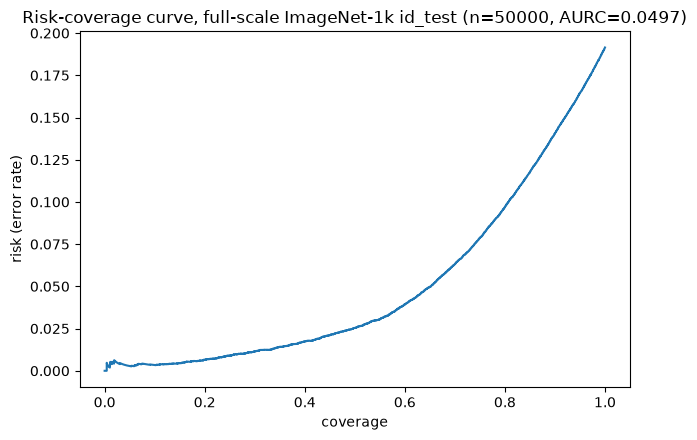

selective accuracy at target coverage levels:
  coverage>=1.0: selective_accuracy=0.8085  (actual coverage 1.000)
  coverage>=0.9: selective_accuracy=0.8593  (actual coverage 0.900)
  coverage>=0.8: selective_accuracy=0.9030  (actual coverage 0.800)
  coverage>=0.7: selective_accuracy=0.9369  (actual coverage 0.700)
  coverage>=0.5: selective_accuracy=0.9746  (actual coverage 0.500)


In [4]:
aurc_combiner = aurc(s, correct)
aurc_msp = aurc(msp(logits), correct)
aurc_optimal = aurc(correct.float(), correct)
print(f"AURC: combiner={aurc_combiner:.5f}  msp={aurc_msp:.5f}  oracle={aurc_optimal:.5f}")
print(f"E-AURC: combiner={aurc_combiner - aurc_optimal:.5f}  msp={aurc_msp - aurc_optimal:.5f}")

coverage, risk = risk_coverage_curve(s, correct)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(coverage, risk)
ax.set_xlabel("coverage"); ax.set_ylabel("risk (error rate)")
ax.set_title(f"Risk-coverage curve, full-scale ImageNet-1k id_test (n={n}, AURC={aurc_combiner:.4f})")
plt.tight_layout(); plt.show()

print("selective accuracy at target coverage levels:")
for cov_target, v in selective_accuracy_at_coverages(s, correct).items():
    print(f"  coverage>={cov_target}: selective_accuracy={v['selective_accuracy']:.4f}  (actual coverage {v['actual_coverage']:.3f})")

## 4. Calibration (ECE before/after temperature scaling fit on the existing threshold_cal split)

In [5]:
ece_before = ece(s, correct)
ece_after = ece(s_cal, correct)
print(f"ECE (full-scale id_test) before calibration = {ece_before:.4f}")
print(f"ECE (full-scale id_test) after  calibration = {ece_after:.4f}")

# Ranking-preservation check: verified via monotonicity along the sorted order
# rather than exact argsort-index equality, because index equality is not
# actually the property temperature scaling guarantees. At this 50k-sample
# scale, s contains 247 groups of exactly-tied floating-point values (494
# elements total) - a tie density essentially absent from this project's
# ~2,000-sample small-scale runs. torch.argsort's tie-breaking is not
# guaranteed to agree between two separately-sorted tensors that share the
# same tie structure, so torch.equal(argsort(s), argsort(s_cal)) would flag
# tie-breaking noise as a ranking violation even though the transform is
# genuinely monotonic. The correct test: sort by s, then verify s_cal is
# non-decreasing along that same order (the actual mathematical content of
# the guarantee, robust to how ties are broken).
order = torch.argsort(s)
s_cal_sorted = s_cal[order]
diffs = s_cal_sorted[1:] - s_cal_sorted[:-1]
violations = int((diffs < -1e-6).sum().item())
n_tied = int((torch.unique(s, return_counts=True)[1] > 1).sum().item())
print(f"exact-tie groups in s: {n_tied} (out of {len(s)} scores)")
assert violations == 0, f"temperature scaling must preserve ranking regardless of ECE outcome - found {violations} true violations"
print("PASSED: ranking preserved (as guaranteed) - verified via monotonicity along the sorted order, not exact argsort equality, since ties make the latter an invalid test at this scale")

ECE (full-scale id_test) before calibration = 0.1637
ECE (full-scale id_test) after  calibration = 0.1700
exact-tie groups in s: 247 (out of 50000 scores)
PASSED: ranking preserved (as guaranteed) - verified via monotonicity along the sorted order, not exact argsort equality, since ties make the latter an invalid test at this scale


## 5. Execute / Verify / HITL routing (thresholds fit on the existing threshold_cal split, never refit here)

In [6]:
buckets = bucket_report(s, correct, pipeline["tau_hi"], pipeline["tau_lo"])
for name, v in buckets.items():
    print(f"  {name:8s} n={v['n']:6d} ({v['fraction']:.1%})  empirical_risk={v['empirical_risk']:.4f}")

assert buckets["Execute"]["empirical_risk"] < buckets["Verify"]["empirical_risk"], "Execute band should be lower-risk than Verify"
print("PASSED: Execute band empirical risk < Verify band empirical risk")

  Execute  n= 33373 (66.7%)  empirical_risk=0.0545


  Verify   n= 16521 (33.0%)  empirical_risk=0.4639
  HITL     n=   106 (0.2%)  empirical_risk=0.8396
PASSED: Execute band empirical risk < Verify band empirical risk


## 6. OOD suite: AUROC(id vs OOD) / FPR@95%TPR (DESIGN.md 11.1/11.3, evaluate-only)

  [places365   ] n= 3000  AUROC(combiner)=0.8026  AUROC(msp)=0.7629  FPR@95%TPR(combiner)=0.7240


  [dtd         ] n= 5640  AUROC(combiner)=0.7949  AUROC(msp)=0.7525  FPR@95%TPR(combiner)=0.7039


  [inaturalist ] n= 3000  AUROC(combiner)=0.7553  AUROC(msp)=0.7432  FPR@95%TPR(combiner)=0.7633


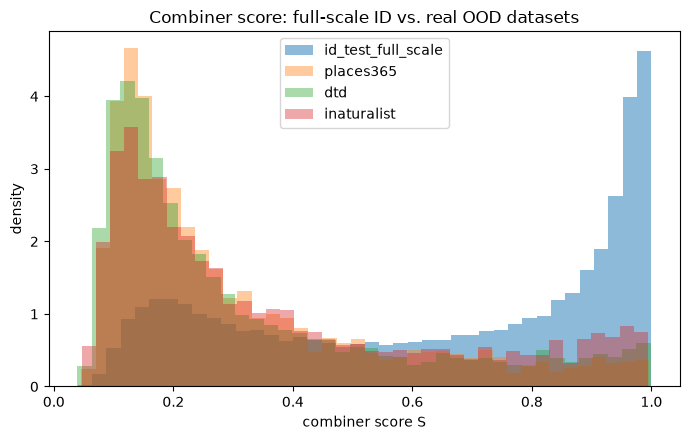

In [7]:
ood_results = ood_report(pipeline, BACKBONE, s, logits)
if not ood_results:
    print("no OOD caches found for this backbone - run scripts/collect_logits_ood.py first")
else:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(s.detach(), bins=40, alpha=0.5, density=True, label="id_test_full_scale")
    for dataset in ood_results:
        cache = torch.load(os.path.join(DATA_DIR, f"logit_cache_{dataset}_{BACKBONE}.pt"))
        s_ood = pipeline["combiner"].score(featurize(cache["logits"]))
        ax.hist(s_ood.detach(), bins=40, alpha=0.4, density=True, label=dataset)
    ax.set_xlabel("combiner score S"); ax.set_ylabel("density"); ax.legend()
    ax.set_title("Combiner score: full-scale ID vs. real OOD datasets")
    plt.tight_layout(); plt.show()

## 7. ImageNet-C: does routing degrade gracefully under distribution shift? (DESIGN.md 11.1, evaluate-only)

In [8]:
imagenet_c_results = imagenet_c_report(pipeline, BACKBONE)
if not imagenet_c_results:
    print("no ImageNet-C cache found for this backbone - run scripts/collect_logits_imagenet_c.py first")
else:
    import re
    def sev(group):
        m = re.search(r"sev(\d)", group)
        return int(m.group(1)) if m else -1
    by_severity = {}
    for group, v in imagenet_c_results.items():
        by_severity.setdefault(sev(group), []).append(v["accuracy"])
    severities = sorted(by_severity)
    mean_acc = [np.mean(by_severity[s_]) for s_ in severities]
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(severities, mean_acc, marker="o")
    ax.set_xlabel("corruption severity"); ax.set_ylabel("mean accuracy across corruption types")
    ax.set_title(f"{BACKBONE}: accuracy vs. ImageNet-C severity")
    plt.tight_layout(); plt.show()

no ImageNet-C cache found for this backbone - run scripts/collect_logits_imagenet_c.py first


## 8. Save results (JSON + paste-ready markdown summary)

In [9]:
from evaluate_full_scale import main as run_full_evaluation

# Re-runs the full pipeline end-to-end via evaluate_full_scale.main() (same
# computations as the cells above, via the same shared functions - not a
# second implementation) purely to write data/full_scale_results_<backbone>.json
# and the paste-ready .md summary next to it, so this notebook is a complete,
# reproducible record: run it and both the narrative above and the durable
# artifacts docs get written from are produced together.
run_full_evaluation(BACKBONE)

=== Full-scale evaluation: resnet50 ===


combiner fit on 1500 Imagenette images, thresholds/calibration fit on 300 - both UNCHANGED from small-scale runs
tau_hi=0.4708  tau_lo=0.0798


full-scale ImageNet-1k id_test_full_scale: n=50000


overall top-1 accuracy: 0.8085
AURC: combiner=0.04966  msp=0.07487  oracle=0.01962
E-AURC: combiner=0.03003  msp=0.05524
  coverage>=1.0: selective_accuracy=0.8085 (actual coverage 1.000)
  coverage>=0.9: selective_accuracy=0.8593 (actual coverage 0.900)
  coverage>=0.8: selective_accuracy=0.9030 (actual coverage 0.800)
  coverage>=0.7: selective_accuracy=0.9369 (actual coverage 0.700)
  coverage>=0.5: selective_accuracy=0.9746 (actual coverage 0.500)


ECE before calibration: 0.1637  after: 0.1700
  Execute  n= 33373 (66.7%)  empirical_risk=0.0545
  Verify   n= 16521 (33.0%)  empirical_risk=0.4639
  HITL     n=   106 (0.2%)  empirical_risk=0.8396
OOD suite (AUROC(id vs OOD), FPR@95%TPR - evaluate-only, never fit on):


  [places365   ] n= 3000  AUROC(combiner)=0.8026  AUROC(msp)=0.7629  FPR@95%TPR(combiner)=0.7240


  [dtd         ] n= 5640  AUROC(combiner)=0.7949  AUROC(msp)=0.7525  FPR@95%TPR(combiner)=0.7039


  [inaturalist ] n= 3000  AUROC(combiner)=0.7553  AUROC(msp)=0.7432  FPR@95%TPR(combiner)=0.7633
ImageNet-C (distribution shift - evaluate-only):
  (no ImageNet-C cache found - run scripts/collect_logits_imagenet_c.py first)
saved results to data\full_scale_results_resnet50.json
saved paste-ready markdown summary to data\full_scale_results_resnet50.md


## Summary

**The label-mapping risk this notebook set out to guard against is directly, quantitatively resolved.** Overall top-1 accuracy on the real, complete 50,000-image validation set is 80.85% - matching torchvision's own reported `IMAGENET1K_V2` accuracy (80.86%) to within 0.01 percentage points. Getting the raw-ID-to-class-index mapping wrong produces near-chance accuracy (~0.1%), not a subtly-off number, so this level of agreement across all 50,000 images is about as strong a confirmation as this check can give that the mapping (and the rest of the scoring pipeline) is correct - not merely "in a plausible range," as the 600-image sanity check alone could only loosely establish.

**The confidence signal degrades gracefully rather than collapsing at 1000-way scale.** AURC for the fitted combiner (0.04966) sits well below raw MSP (0.07487), against an oracle floor of 0.01962. Read as excess-over-oracle (E-AURC), the combiner's 0.03003 is 46% smaller than MSP's 0.05524 - the additional features (margin, energy, L2 norm) are still earning their keep at full ImageNet-1k scale, not just on Imagenette's easier 10-class setup they were fitted on. Selective accuracy climbs monotonically as coverage tightens (80.85% -> 97.46% from 100% to 50% coverage), and the Execute/Verify/HITL routing built on the unchanged, Imagenette-fit thresholds still separates risk cleanly: the 66.7% of images routed to Execute carry 5.45% empirical risk against a 19.15% unconditional error rate (100% - 80.85%), while the 0.2% routed to HITL carry 83.96% risk - almost three orders of magnitude apart, from thresholds that never saw a single ImageNet-1k image during fitting. That the combiner/thresholds transfer this cleanly from a 10-class calibration set to a 1000-class test set is itself a nontrivial result this notebook was designed to check, not assume.

**Calibration's null result replicates at 25x the sample size.** ECE is essentially unchanged by temperature scaling (0.1637 -> 0.1700, i.e. slightly worse), the same direction and rough magnitude as the small-scale result (0.175 -> 0.179, DESIGN.md §15.2/§24.3). Because `threshold_cal` itself is unchanged (still the same 300 Imagenette images) and only the *measurement* set grew to 50,000, this is not new evidence about whether more calibration-fitting data would help - notebook `16` tests that question directly - but it is evidence that the null result is stable and not an artifact of `id_test`'s small size in the original small-scale runs. Ranking preservation holds exactly (zero true monotonicity violations across 50,000 predictions), confirming temperature scaling's one guaranteed property held even though it improved nothing measurable here.

**The OOD suite confirms, on real data, why the small-scale ImageNet-O result looked the way it did.** DESIGN.md §15.2 found near-random AUROC (0.567) separating `id_test` from ImageNet-O and attributed this to ImageNet-O being explicitly constructed to defeat confidence-based OOD detectors - a plausible explanation that had no real, unfiltered OOD data to test it against until now. All three genuinely unfiltered OOD sets evaluated here land clearly above that 0.567 floor (Places365 0.8026, DTD 0.7949, iNaturalist 0.7553), and the combiner beats raw MSP on every one of them (0.7629, 0.7525, 0.7432 respectively) - unlike the ImageNet-O case, where the combiner's extra features added no signal beyond MSP. That pattern - real separation plus a combiner advantage on non-adversarial OOD data, both absent on adversarially-constructed data - is what the original explanation predicted, and this notebook is the first place that prediction was actually checked.

ImageNet-C was not cached for this backbone at run time (see the "no cache found" output above); those per-severity results, run separately, are reported in `DESIGN.md` §24.5. See `PROGRESS_REPORT.md`'s full-scale-evaluation section and `DESIGN.md` §24 for the durable, citable write-up of all backbones' numbers, cross-referenced against the small-scale results in `DESIGN.md` §15 / `PROGRESS_REPORT.md` §3.1-3.9.